# Injection-January mixed-layer depth

Regional zooms of the **injection-January mixed-layer depth** (`mld_inject_jan` in the
bad-curve cache: HMXL for Jan 1999 from the SMYLE-FOSI reference run, the physics the
whole atlas branches from) with the atlas polygon **footprint outlines** overlaid, each
labelled by polygon id.  Every panel is scaled independently (2nd-98th percentile of the
MLD over the footprints in view) so within-region structure stays visible; the printed
table lists the footprint-area-weighted mean January MLD for each polygon in the window.

Zooms: Labrador Sea (polygon 000), circum-Antarctic, and the regions around polygons
151, 437, 027 and 140.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pop_tools

import bad_curves_analysis as B

cache = B.open_cache()

In [27]:
# pop_tools grid for clean mesh coordinates (history-file TLONG/TLAT carry a _FillValue)
grid = pop_tools.get_grid("POP_gx1v7")
TLONG, TLAT, KMT = grid.TLONG.values, grid.TLAT.values, grid.KMT.values

mld = np.where(KMT > 0, cache.mld_inject_jan.values, np.nan)   # 2-D January MLD [m]

# Ocean bottom depth: accumulate layer thicknesses up to KMT levels
_dz = grid.dz.values   # (nlev,) in cm
_depth_cm = np.zeros_like(KMT, dtype=float)
for _k, _dz_k in enumerate(_dz):
    _depth_cm += _dz_k * (KMT > _k)
depth_m = np.where(KMT > 0, _depth_cm / 100.0, np.nan)         # 2-D ocean depth [m]

plat = cache.centroid_lat.values
plon = cache.centroid_lon.values
plon180 = ((plon + 180) % 360) - 180
pmld = cache.poly_mld_inject_jan.values                        # per-polygon footprint mean

masks = B.load_forcing_footprints("oae")                       # (polygon, nlat, nlon) bool


def _outline(ax, i, **kw):
    "Contour polygon i's footprint boundary, windowed to its own grid box."
    m = masks[i]
    if not m.any():
        return
    rr = np.where(m.any(axis=1))[0]
    cc = np.where(m.any(axis=0))[0]
    r0, r1 = max(rr[0] - 2, 0), rr[-1] + 3
    c0, c1 = max(cc[0] - 2, 0), cc[-1] + 3
    lon = TLONG[r0:r1, c0:c1]
    if np.ptp(TLONG[m]) > 180:            # footprint straddles the 0/360 seam
        lon = ((lon + 180) % 360) - 180
    ax.contour(lon, TLAT[r0:r1, c0:c1], m[r0:r1, c0:c1].astype(float),
               levels=[0.5], transform=ccrs.PlateCarree(), zorder=6, **kw)


def _scale(sel):
    "Robust colour limits from the footprints of the polygons in view."
    u = np.zeros_like(KMT, dtype=bool)
    for i in sel:
        u |= masks[i]
    v = mld[u]
    v = v[np.isfinite(v)]
    lo, hi = np.nanpercentile(v, [2, 98])
    return max(0.0, np.floor(lo / 5) * 5), np.ceil(hi / 10) * 10


def _finish(fig, ax, pm, sel, title, fname):
    for i in sel:
        _outline(ax, i, colors="w", linewidths=0.7)
        ax.text(plon180[i], plat[i], f"{i:03d}", fontsize=6, color="w",
                ha="center", va="center", transform=ccrs.PlateCarree(), zorder=7)
    fig.colorbar(pm, ax=ax, orientation="horizontal", shrink=0.7, pad=0.05,
                 label="m")
    ax.set_title(title, y=1.05)
    fig.savefig(fname, dpi=200, bbox_inches="tight")


def zoom_mld(lon0, lon1, lat0, lat1, title, fname):
    "Rectangular zoom (lon/lat in -180..180)."
    clon = 0.5 * (lon0 + lon1)
    sel = [i for i in range(B.N_POLYGONS)
           if np.isfinite(plat[i]) and lat0 <= plat[i] <= lat1
           and lon0 <= plon180[i] <= lon1]
    vmin, vmax = _scale(sel)
    fig, ax = plt.subplots(figsize=(11, 8),
                           subplot_kw={"projection": ccrs.PlateCarree(central_longitude=clon)})
    ax.set_extent([lon0, lon1, lat0, lat1], ccrs.PlateCarree())
    pm = ax.pcolormesh(TLONG, TLAT, mld, cmap="viridis", vmin=vmin, vmax=vmax,
                       transform=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    ax.coastlines(linewidth=0.6)
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray")
    gl.top_labels = gl.right_labels = False
    _finish(fig, ax, pm, sel, title, fname)


def zoom_mld_south(lat_max, title, fname):
    "Circum-Antarctic zoom: everything south of lat_max."
    sel = [i for i in range(B.N_POLYGONS) if np.isfinite(plat[i]) and plat[i] <= lat_max]
    vmin, vmax = _scale(sel)
    fig, ax = plt.subplots(figsize=(10, 10),
                           subplot_kw={"projection": ccrs.SouthPolarStereo()})
    ax.set_extent([-180, 180, -90, lat_max], ccrs.PlateCarree())
    theta = np.linspace(0, 2 * np.pi, 200)
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T * 0.5 + 0.5
    ax.set_boundary(mpath.Path(verts), transform=ax.transAxes)
    pm = ax.pcolormesh(TLONG, TLAT, mld, cmap="viridis", vmin=0, vmax=vmax,
                       transform=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
    ax.coastlines(linewidth=0.6)
    ax.gridlines(linewidth=0.3, color="gray")
    _finish(fig, ax, pm, sel, title, fname)

In [28]:
def _scale_depth(sel):
    "Robust colour limits for ocean depth over the footprints of the polygons in view."
    u = np.zeros_like(KMT, dtype=bool)
    for i in sel:
        u |= masks[i]
    v = depth_m[u]
    v = v[np.isfinite(v)]
    lo, hi = np.nanpercentile(v, [2, 98])
    return max(0.0, np.floor(lo / 100) * 100), np.ceil(hi / 100) * 100


def _finish_pair(fig, axes, pm_mld, pm_dep, sel, title, fname):
    "Add outlines, labels, colorbars, save — for a two-panel (MLD | depth) figure."
    for ax, pm, label in zip(axes,
                              [pm_mld, pm_dep],
                              ["injection-January MLD [m]", "ocean depth [m]"]):
        for i in sel:
            _outline(ax, i, colors="w", linewidths=0.7)
            ax.text(plon180[i], plat[i], f"{i:03d}", fontsize=6, color="w",
                    ha="center", va="center", transform=ccrs.PlateCarree(), zorder=7)
        fig.colorbar(pm, ax=ax, orientation="horizontal", shrink=0.7, pad=0.05, label=label)
    fig.suptitle(title, y=1.01)
    fig.savefig(fname, dpi=200, bbox_inches="tight")


def zoom_mld_depth(lon0, lon1, lat0, lat1, title, fname):
    "Side-by-side rectangular zoom: January MLD (left) and ocean depth (right)."
    clon = 0.5 * (lon0 + lon1)
    sel = [i for i in range(B.N_POLYGONS)
           if np.isfinite(plat[i]) and lat0 <= plat[i] <= lat1
           and lon0 <= plon180[i] <= lon1]
    mld_lo, mld_hi = _scale(sel)
    dep_lo, dep_hi = _scale_depth(sel)
    proj = ccrs.PlateCarree(central_longitude=clon)
    fig, axes = plt.subplots(1, 2, figsize=(18, 6),
                             subplot_kw={"projection": proj})
    for ax in axes:
        ax.set_extent([lon0, lon1, lat0, lat1], ccrs.PlateCarree())
        ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
        ax.coastlines(linewidth=0.6)
        gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray")
        gl.top_labels = gl.right_labels = False
    pm_mld = axes[0].pcolormesh(TLONG, TLAT, mld, cmap="viridis",
                                vmin=mld_lo, vmax=mld_hi, transform=ccrs.PlateCarree())
    pm_dep = axes[1].pcolormesh(TLONG, TLAT, depth_m, cmap="Blues",
                                vmin=dep_lo, vmax=dep_hi, transform=ccrs.PlateCarree())
    axes[0].set_title("January MLD")
    axes[1].set_title("Ocean depth")
    _finish_pair(fig, axes, pm_mld, pm_dep, sel, title, fname)


def zoom_mld_depth_south(lat_max, title, fname, depth_vmax=None):
    "Side-by-side circum-Antarctic zoom: January MLD (left) and ocean depth (right)."
    sel = [i for i in range(B.N_POLYGONS) if np.isfinite(plat[i]) and plat[i] <= lat_max]
    mld_lo, mld_hi = _scale(sel)
    dep_lo, dep_hi = _scale_depth(sel)
    if depth_vmax is not None:
        dep_hi = depth_vmax
    fig, axes = plt.subplots(1, 2, figsize=(16, 8),
                             subplot_kw={"projection": ccrs.SouthPolarStereo()})
    theta = np.linspace(0, 2 * np.pi, 200)
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T * 0.5 + 0.5
    for ax in axes:
        ax.set_extent([-180, 180, -90, lat_max], ccrs.PlateCarree())
        ax.set_boundary(mpath.Path(verts), transform=ax.transAxes)
        ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
        ax.coastlines(linewidth=0.6)
        ax.gridlines(linewidth=0.3, color="gray")
    pm_mld = axes[0].pcolormesh(TLONG, TLAT, mld, cmap="viridis",
                                vmin=0, vmax=mld_hi, transform=ccrs.PlateCarree())
    pm_dep = axes[1].pcolormesh(TLONG, TLAT, depth_m, cmap="Blues",
                                vmin=0, vmax=dep_hi, transform=ccrs.PlateCarree())
    axes[0].set_title("January MLD")
    axes[1].set_title("Ocean depth")
    _finish_pair(fig, axes, pm_mld, pm_dep, sel, title, fname)

## Labrador Sea — polygon 000

January is peak deep-convection season here; polygon 000 sits in the deepest-MLD band of the basin.

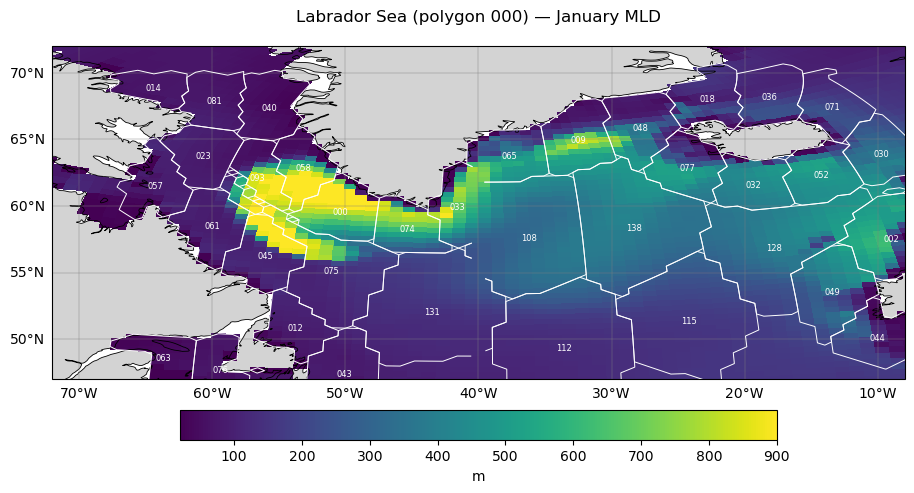

In [29]:
zoom_mld(-72, -8, 47, 72, "Labrador Sea (polygon 000) — January MLD",
         "figures/mld_january_labsea.png")

## Circum-Antarctic

January is austral summer, so Southern Ocean mixed layers are shallow everywhere.

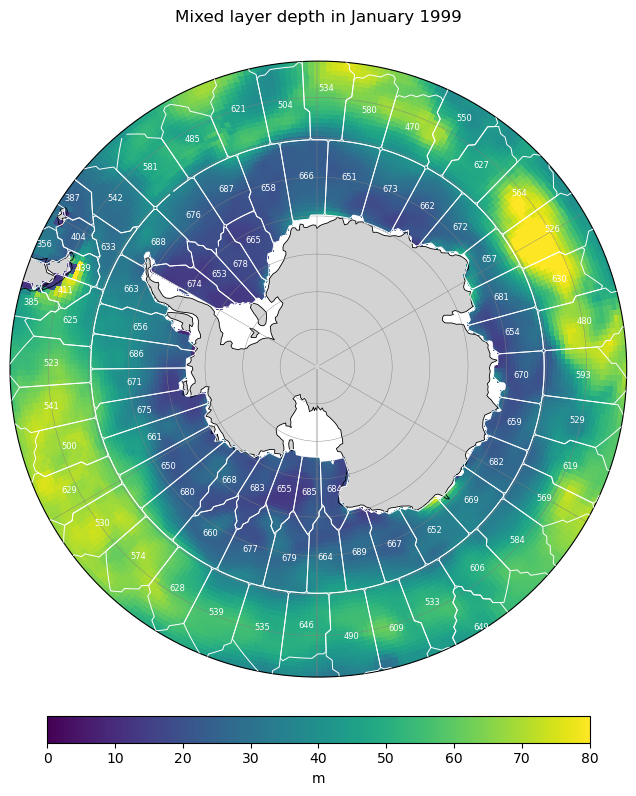

In [30]:
zoom_mld_south(-50, "Mixed layer depth in January 1999", "figures/mld_january_antarctic.png")

## Around polygon 151 — Philippine Sea

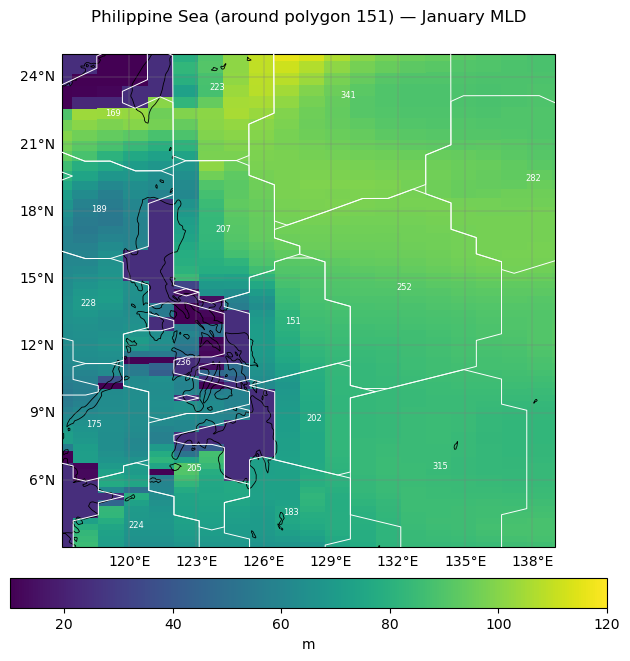

In [31]:
zoom_mld(117, 139, 3, 25, "Philippine Sea (around polygon 151) — January MLD",
         "figures/mld_january_p151.png")

## Around polygon 437 — Arabian Sea

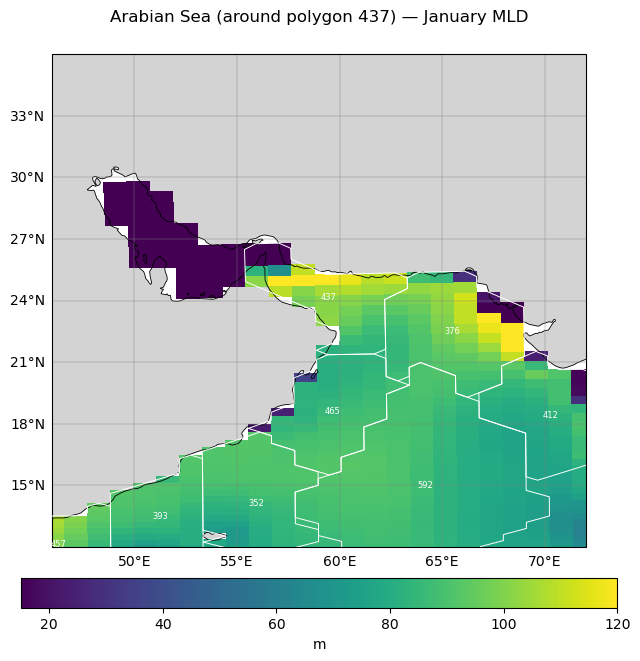

In [32]:
zoom_mld(46, 72, 12, 36, "Arabian Sea (around polygon 437) — January MLD",
         "figures/mld_january_p437.png")

## Around polygon 027 — NE subtropical Atlantic

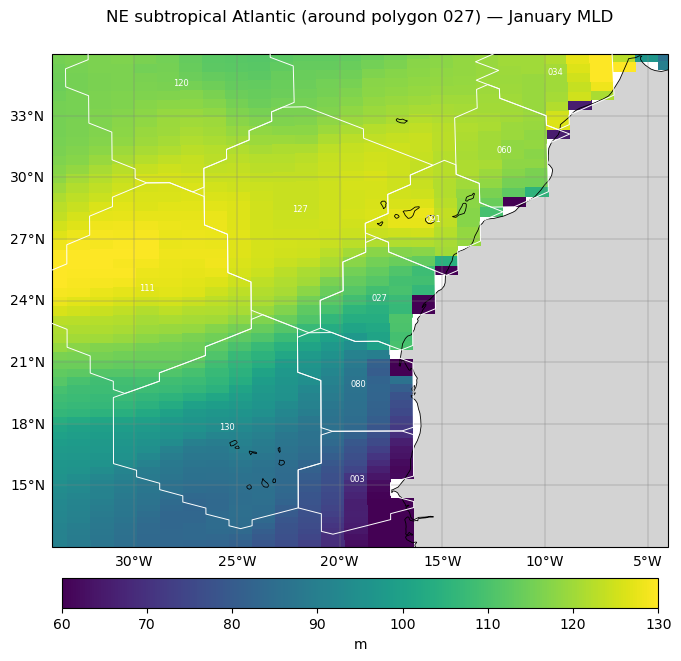

In [33]:
zoom_mld(-34, -4, 12, 36, "NE subtropical Atlantic (around polygon 027) — January MLD",
         "figures/mld_january_p027.png")

## Around polygon 140 — central subtropical N Atlantic

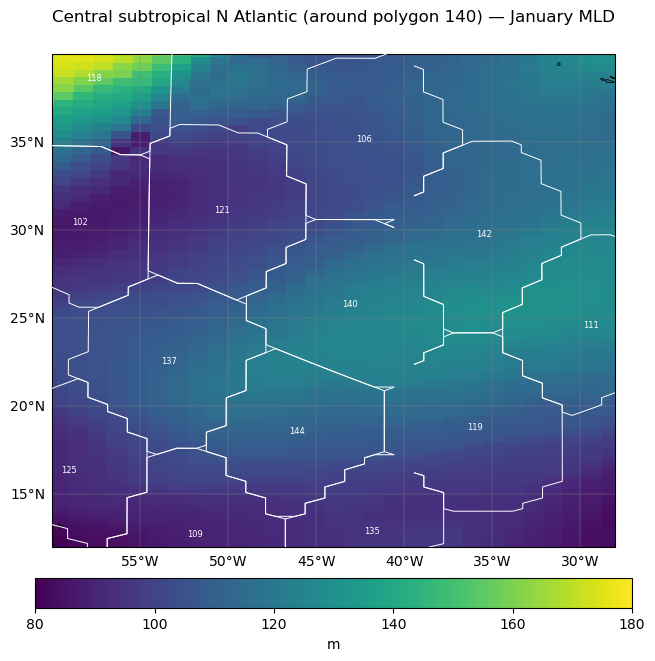

In [34]:
zoom_mld(-60, -28, 12, 40, "Central subtropical N Atlantic (around polygon 140) — January MLD",
         "figures/mld_january_p140.png")

---
# Side-by-side: January MLD and ocean depth

Same regional windows as above, now showing January MLD and ocean bottom depth side by side.
Each panel has its own colour scale (2nd–98th percentile over the footprints in view).

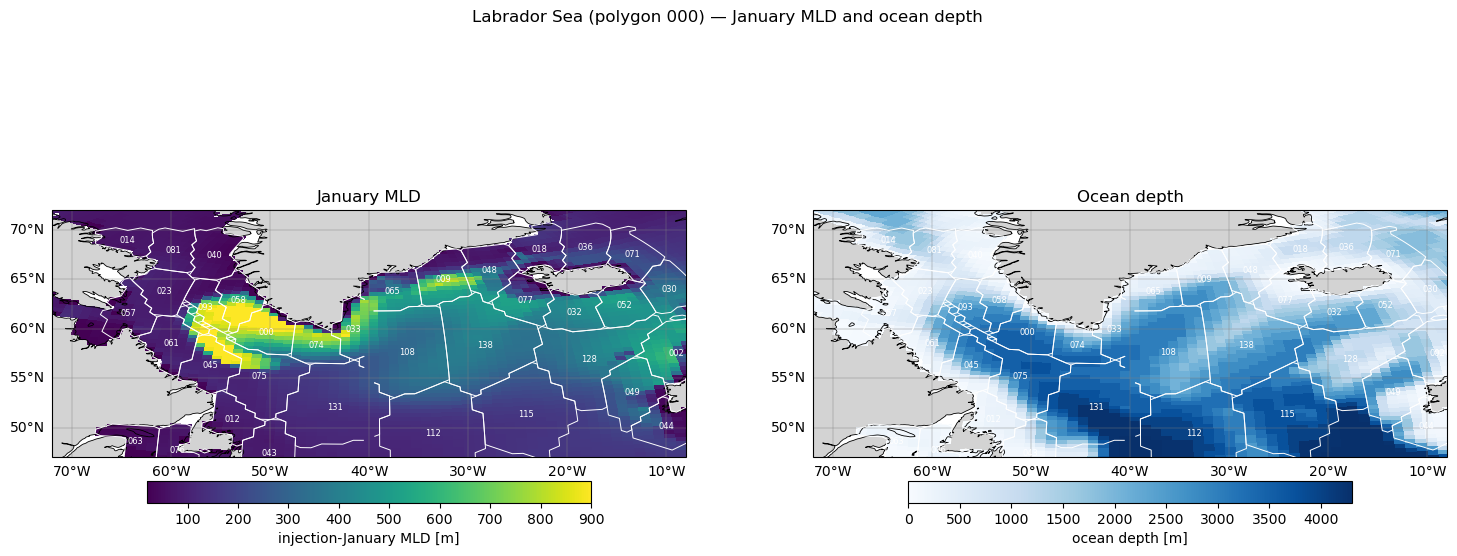

In [6]:
zoom_mld_depth(-72, -8, 47, 72,
               "Labrador Sea (polygon 000) — January MLD and ocean depth",
               "figures/mld_depth_labsea.png")

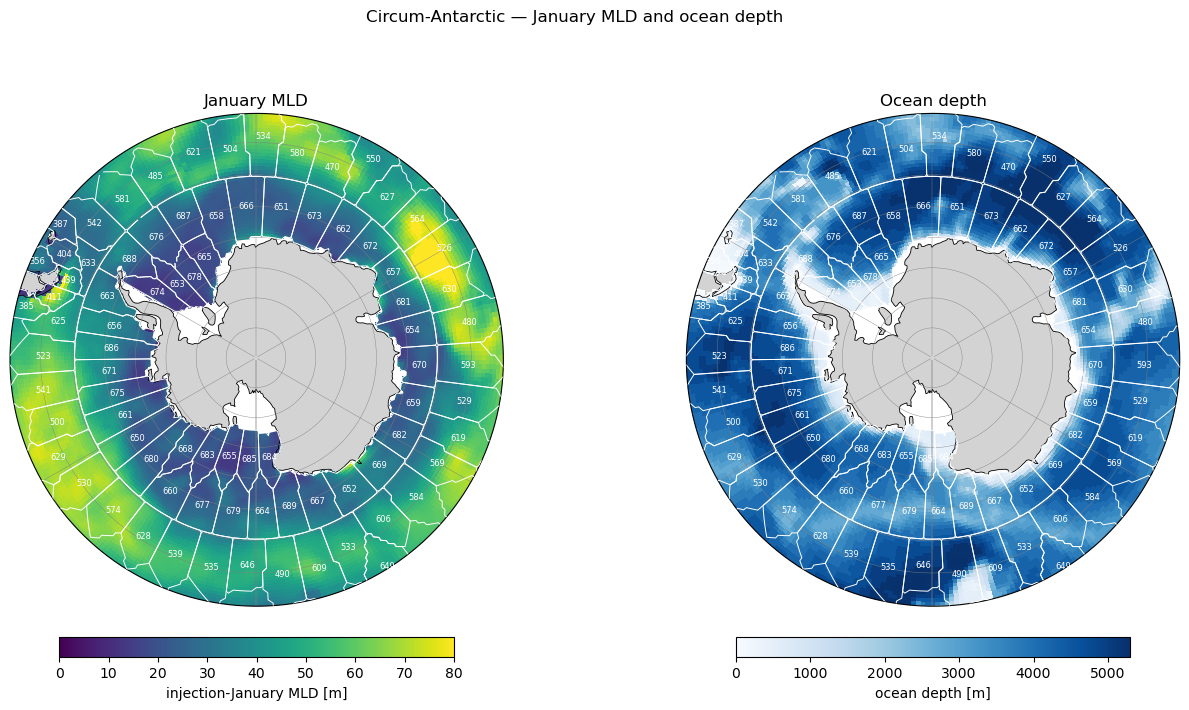

In [13]:
zoom_mld_depth_south(-50,
                     "Circum-Antarctic — January MLD and ocean depth",
                     "figures/mld_depth_antarctic.png")

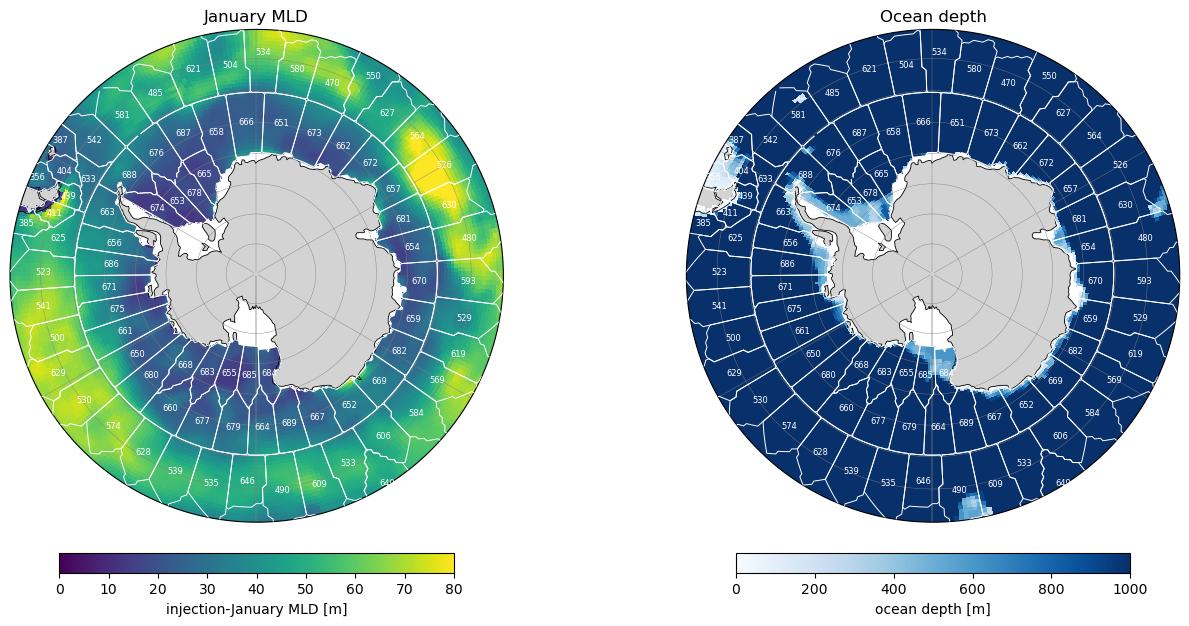

In [21]:
zoom_mld_depth_south(-50, depth_vmax=1000, title="", fname="figures/mld_depth_antarctic_cbar_sat.png")

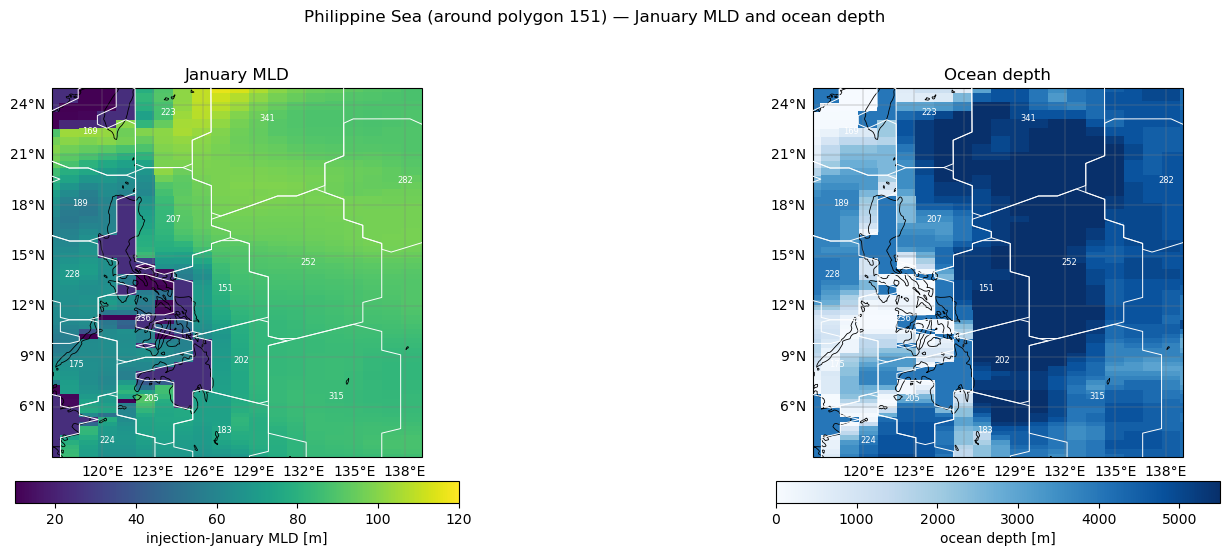

In [8]:
zoom_mld_depth(117, 139, 3, 25,
               "Philippine Sea (around polygon 151) — January MLD and ocean depth",
               "figures/mld_depth_p151.png")

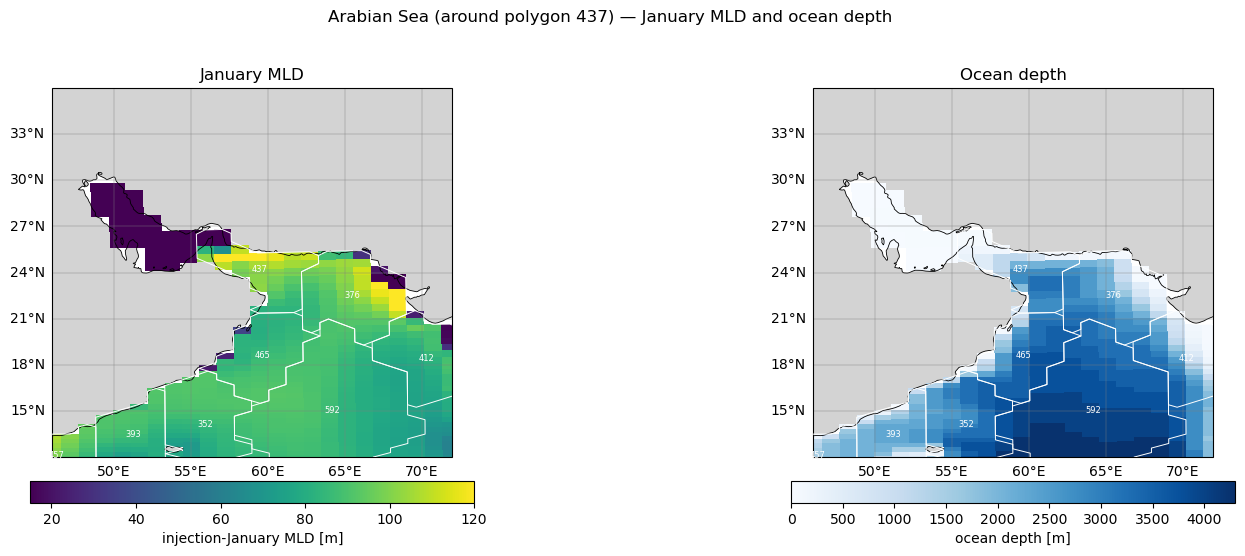

In [9]:
zoom_mld_depth(46, 72, 12, 36,
               "Arabian Sea (around polygon 437) — January MLD and ocean depth",
               "figures/mld_depth_p437.png")

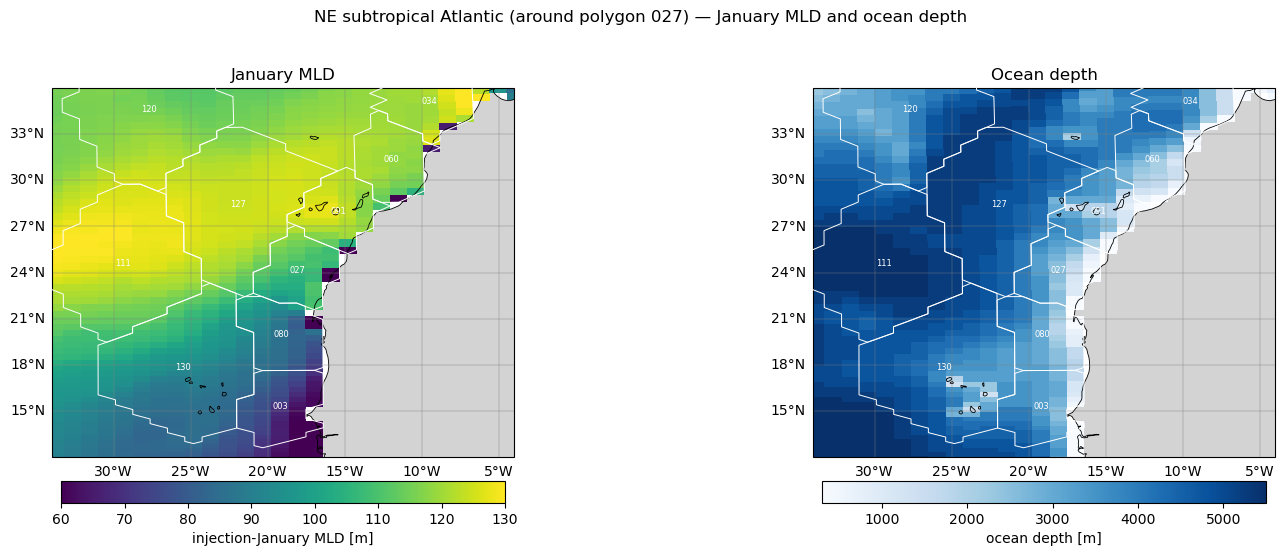

In [10]:
zoom_mld_depth(-34, -4, 12, 36,
               "NE subtropical Atlantic (around polygon 027) — January MLD and ocean depth",
               "figures/mld_depth_p027.png")

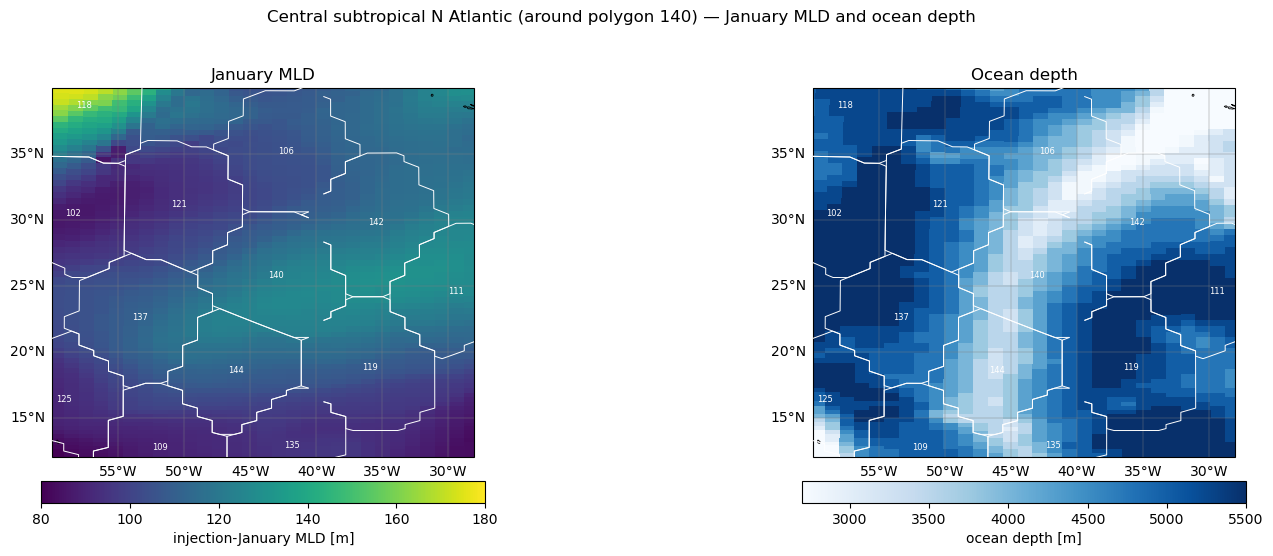

In [11]:
zoom_mld_depth(-60, -28, 12, 40,
               "Central subtropical N Atlantic (around polygon 140) — January MLD and ocean depth",
               "figures/mld_depth_p140.png")

---
# Global maps

Same fields as the zooms above, without a window: injection-January MLD, the annual-mean MLD, and
their ratio. The ratio is the useful one for the seasonal question - it says how *wintry* January
is at each location, independently of how deep the mixed layer is in absolute terms.

Both 2-D fields come from the bad-curve cache (`mld_inject_jan`, `mld_mean_all`; SMYLE-FOSI HMXL,
metres).

In [17]:
from matplotlib.colors import LogNorm, TwoSlopeNorm

mld_jan  = np.where(KMT > 0, cache.mld_inject_jan.values, np.nan)
mld_mean = np.where(KMT > 0, cache.mld_mean_all.values,  np.nan)


def global_map(field, title, label, fname, cmap="viridis", norm=None,
               vmin=None, vmax=None, contour=None):
    fig, ax = plt.subplots(figsize=(13, 6.5),
                           subplot_kw={"projection": ccrs.Robinson(central_longitude=-160)})
    kw = dict(cmap=cmap, transform=ccrs.PlateCarree())
    if norm is not None:
        kw["norm"] = norm
    else:
        kw["vmin"], kw["vmax"] = vmin, vmax
    pm = ax.pcolormesh(TLONG, TLAT, field, **kw)
    if contour is not None:
        ax.contour(TLONG, TLAT, field, levels=[contour], colors="k", linewidths=0.6,
                   transform=ccrs.PlateCarree(), zorder=5)
    ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=3)
    ax.coastlines(linewidth=0.4, zorder=4)
    ax.gridlines(linewidth=0.3, color="gray")
    ax.set_global()
    fig.colorbar(pm, ax=ax, orientation="horizontal", shrink=0.65, pad=0.05, label=label)
    ax.set_title(title)
    fig.savefig(fname, dpi=200, bbox_inches="tight")
    return fig

## Injection-January MLD

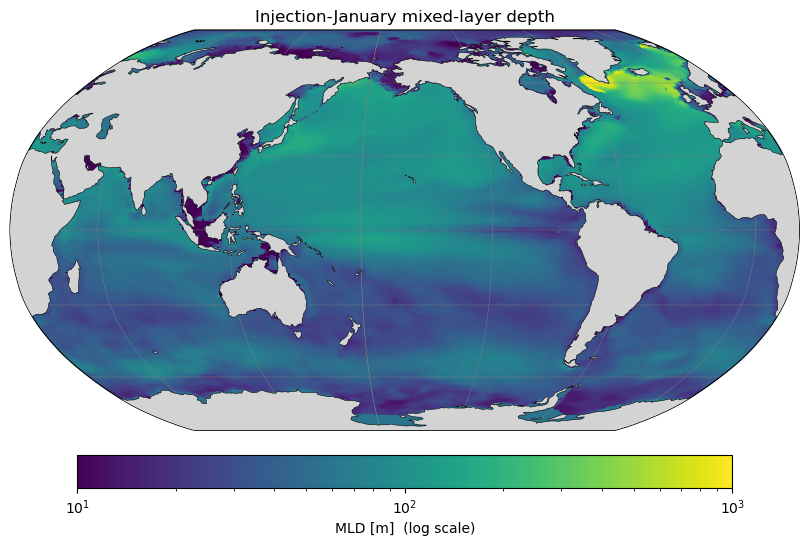

In [18]:
fig = global_map(mld_jan, "Injection-January mixed-layer depth",
                 "MLD [m]  (log scale)", "figures/mld_january_global.png",
                 norm=LogNorm(vmin=10, vmax=1000))

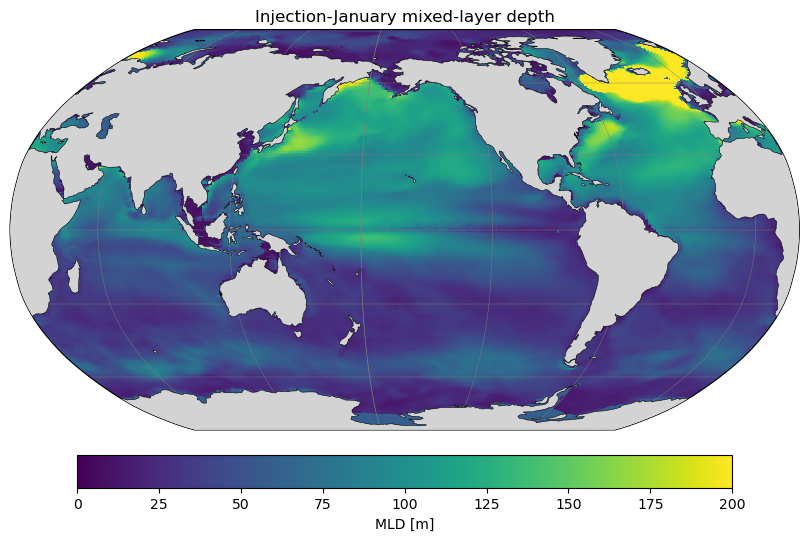

In [23]:
fig = global_map(mld_jan, "Injection-January mixed-layer depth",
                 "MLD [m]", "figures/mld_january_global.png",
                 vmin=0, vmax=200)

## Annual-mean MLD

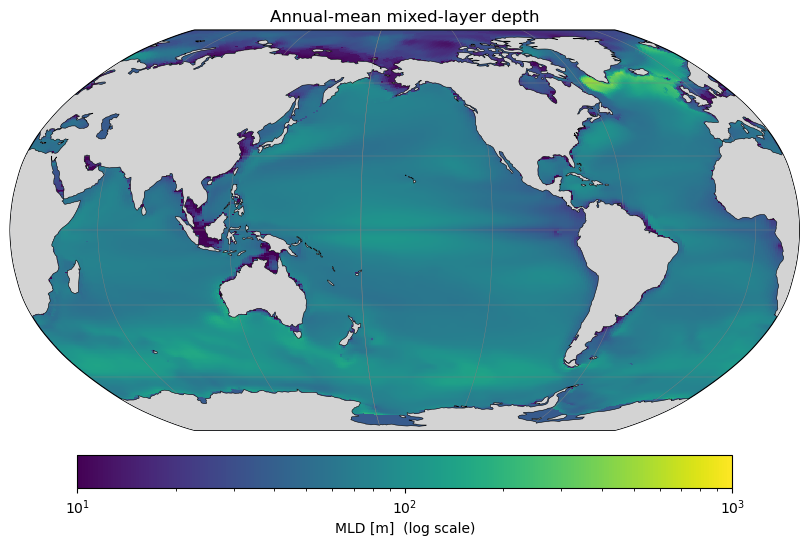

In [11]:
fig = global_map(mld_mean, "Annual-mean mixed-layer depth",
                 "MLD [m]  (log scale)", "figures/mld_annualmean_global.png",
                 norm=LogNorm(vmin=10, vmax=1000))

## Ocean bottom depth

In [ ]:
fig = global_map(depth_m, "Ocean bottom depth",
                 "depth [m]", "figures/depth_global.png",
                 cmap="Blues", vmin=0, vmax=6000)